# Re-checking earlier logic-metric results across label sets

This notebook demonstrates **`eval.py`** from the evaluation artifact *"Re-checking earlier logic-metric results across label sets"*.
It is a CPU-only re-analysis that makes **no LLM calls**. It covers metrics that try to predict whether a candidate
first-order-logic (FOL) formalization is faithful to its natural-language sentence, **without a gold formula**.

**Context.** Iteration 1 of the project produced per-item scores from several metric families on the same FOLIO-dev
candidates (Logic-LM outputs of gpt-3.5 / gpt-4 / text-davinci-003):

| Source | Metrics (every score oriented so that **higher = more likely ERROR**) |
|---|---|
| exp A (FOL-Triage) | `p_fused_H` (fused triage), `bow_uncarried` (L2 bag-of-words: content words the FOL drops), `l3_score`, `n_smells`, `role_count` |
| exp C (sampling consensus) | `c_score` (disagreement with peer samples), `medoid_depth`, `cluster_entropy`, `sc5_cheap` |
| exp D (judges / baselines) | `judge_cheap_disg`/`orig` (cheap LLM judge, disguised/original prompt), round-trip NLI/embedding, parse-fail, pilot structural metrics |
| dataset E (adjudication) | independent re-labels (tiers A/B/auto_only) of the same items |

Different experiments labelled the same items differently (prover-checked "solver" labels vs. adjudicated labels).
`eval.py` asks: **do the iteration-1 conclusions hold if every metric is scored on the same items with the same label?**

What the script does (and what this notebook runs):
1. **Step 3 – label regimes:** declare every label set (solver-consistent, each experiment's own labels, adjudicated tiers, contested->C/E, unparseable-as-error).
2. **Step 6 – PEER+TEXT preview:** cross-fitted logistic combos (`PT` = c_score + bow_uncarried + l3_score, and variants).
3. **Step 4 – common-item tables:** per regime, AUROC with sentence-cluster bootstrap CIs, delta vs. the cheap judge, DeLong tests, Holm correction, and the iteration-1 decision rule verdicts.
4. **Step 5 – regime shift:** label-only AUROC shift on shared items, Kendall-tau of metric rankings, flipped-item diagnostic.
5. **Step 7 – P1/P2 mechanism checks:** recall per error type at matched false-alarm rate, and a decomposition of the PT gain into endorsed and non-endorsed errors.

Steps 0-2 (input hashing, bookkeeping, re-deriving the reviewer's audit numbers) and 8-13 (must-fix audits, judge contamination,
invariance, complexity) need ~50 raw files from other experiments, so they are **not** part of this demo. The demo runs on a
**100-item track-L subset** (`mini_demo_data.json`) of the joined master table, so its numbers are noisier than the full run
(1,037 track-L items). The last cell compares the two.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib -- pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# ---- original eval.py import block
import gc
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# ---- imports of the src/ modules (stats_utils, steps_core, steps_models)
import hashlib
import itertools
import math
import random
import re
from collections import Counter
from types import SimpleNamespace

from scipy import stats
from scipy import stats as sps
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# ---- notebook additions (results figure)
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-2/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("items:", len(data["items"]), "| side inputs:", [k for k in data if k not in ("items", "description")])

100 track-L items (FOLIO-dev Logic-LM candidates, 2023 systems) of the iteration-1 master frame joined on item_id (exp A FOL-Triage, exp C consensus, exp D judges/baselines, dataset E adjudication). Every score oriented so higher = more likely ERROR. Chosen with seed 0: 14 solver-CORRECT->adjudicated-ERROR items, 46 other items in both R_SOLVER_CONS and R_ADJ_AB common sets, 10 all-UNPARSEABLE items, 30 R_SOLVER_CONS-only items.
items: 100 | side inputs: ['d_thresholds', 'd_dev_slice_ids', 'd_folds', 'shipped_rule_inputs', 'full_run_reference']


## Configuration

All tunable parameters. `eval.py` has two modes: full (`B=2000`, 5 fold seeds, 500 Kendall-tau resamples) and `--quick`
(`B=200`, 1 seed, 100 resamples). On the 100-item demo subset the **original full-run values** below take about 20-30 s,
so they are used as-is. Lower them (e.g. to the `--quick` values) for an even faster pass. Note that `step6_regime` and
`step5_regime_shift` use a fixed internal `B=2000` for some CIs, exactly as in the original.

In [5]:
B = 2000         # sentence-cluster bootstrap resamples for every CI       (original full run: 2000; --quick: 200)
N_SEEDS = 5      # fold seeds for the cross-fitted PEER+TEXT models      (original full run: 5;    --quick: 1)
B_TAU = 500      # resamples for the Kendall-tau CI of metric rankings   (original full run: 500;  --quick: 100)
TABLES_DIR = Path("tables")   # eval.py writes its CSV tables here (WS / "tables")

## Master frame (replaces `load.load_all()` + `load.build_master()`)

In the original, `src/load.py` reads the per-item files of exp A, C, D and dataset E and joins them on `item_id` into one
frame (one row per candidate formalization: text, candidate FOL, each experiment's label, every oriented score, and
`cluster` = normalised sentence text used as the bootstrap cluster). `mini_demo_data.json` holds 100 rows of exactly that
frame. The side inputs `eval.py` reads from other artifacts are loaded from the same file: exp D's decision thresholds, exp D's
cross-validation folds, the judge-prompt dev slice, and the shipped coverage/cost/rewrite-FA values of the iteration-1 rule.

In [6]:
df = pd.DataFrame(data["items"]).set_index("item_id", drop=False)
# load._f() turns every score into a float (None -> NaN); do the same for the JSON-loaded columns
_non_numeric = {"item_id", "track", "system", "text", "candidate_fol", "reference_fol", "cluster", "in_A", "in_C", "in_D", "in_E",
                "lab_A", "lab_C", "lab_D", "lab_D_hcur", "E_auto_label", "E_final_label", "E_label_tier", "E_reading_choice",
                "E_repair_ops", "E_addrop_only_suspect", "ops_A", "ops_C", "ops_D"}
for c in df.columns:
    if c not in _non_numeric:
        df[c] = df[c].astype(float)

d_folds = data["d_folds"]          # exp D data/folds.json (item_id -> fold), restricted to the demo items
d_thr = data["d_thresholds"]       # exp D results/analysis.json["thresholds"]
print(f"master frame: {len(df)} rows; tracks={df['track'].value_counts().to_dict()}")
df[["system", "text", "candidate_fol", "lab_A", "lab_C", "lab_D", "E_final_label", "E_label_tier", "c_score", "bow_uncarried", "judge_cheap_disg"]].head()

master frame: 100 rows; tracks={'L': 100}


,system,text,candidate_fol,lab_A,lab_C,lab_D,E_final_label,E_label_tier,c_score,bow_uncarried,judge_cheap_disg
item_id,,,,,,,,,,,
00b1b9552be255b7,gpt-3.5-turbo,Walden contains knowledge.,"Contain(walden, knowledge)",CORRECT,CORRECT,CORRECT,CORRECT,B,0.125,0.000000,0.05
052738ebdc4ef431,text-davinci-003,At least one event is happy.,∃x (Happy(x)),ERROR,ERROR,ERROR,ERROR,auto_only,0.125,0.500000,0.05
05589aa50bda1d39,gpt-4,Montana is home to the city of Missoula.,"In(missoula, montana)",ERROR,ERROR,ERROR,ERROR,A,0.500,0.500000,1.00
05a389bf74f0a19d,text-davinci-003,Beethoven leads the Vienna Music Society.,"Lead(beethoven, viennaMusicSociety)",CORRECT,CORRECT,CORRECT,CORRECT,A,0.000,0.000000,1.00
07a86e965863573b,gpt-4,No digital media are analog.,∀x (Digital(x) → ¬Analog(x)),CORRECT,CORRECT,CORRECT,ERROR,B,0.125,0.333333,0.00


## Statistics primitives (`src/stats_utils.py`, verbatim)

* **AUROC** = Mann-Whitney statistic, ties count 0.5. Label `y`: 1 = ERROR, 0 = CORRECT.
* **ClusterBoot**: resample *sentences* with replacement. An item's weight in a resample is its sentence's multiplicity,
  because several systems' candidates for the same sentence are not independent.
* `boot_auc_w` computes the weighted AUROC for all B resamples at once, using matrix products on the unique score levels.
* **DeLong** paired test (plain, and Obuchowski's clustered version), **Holm** correction, and a randomised
  **matched-false-alarm threshold** so that recall can be compared at exactly FA = 0.10 / 0.20.

In [7]:
B_RESAMPLES = 2000


SEED = 0


# exp D src/common.py::norm (gen_art_experiment_4/src/common.py lines 23-29), copied verbatim
_QUOTES = str.maketrans({"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "−": "-"})


def norm(s: str) -> str:
    """Exp D's GroupKFold / bootstrap cluster key: lower-case, quotes unified, punctuation -> space, spaces collapsed."""
    s = (s or "").translate(_QUOTES).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


# exp C src/common.py line 23 (COARSE) and lines 48-52 (op_class), copied verbatim
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def op_class(ops: list[str]) -> str:
    """Exp C's coarse operator class of a repair set: POLARITY / COVERAGE / STRUCT / MIXED (NONE if empty)."""
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


# ----------------------------------------------------------------------------------------------- point statistics
def auroc(y: np.ndarray, s: np.ndarray) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, s))


def auprc(y: np.ndarray, s: np.ndarray) -> float:
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(average_precision_score(y, s))


def tie_fraction(y: np.ndarray, s: np.ndarray) -> float:
    """Share of (ERROR, CORRECT) pairs whose scores are tied (Deutsch et al. 2023 'Ties Matter')."""
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    cp, cn = Counter(np.round(pos, 9).tolist()), Counter(np.round(neg, 9).tolist())
    return sum(cp[v] * cn.get(v, 0) for v in cp) / (len(pos) * len(neg))


def ppv_at_prevalence(tpr: float | None, fpr: float | None, pi: float) -> float | None:
    """PPV = TPR*pi / (TPR*pi + FPR*(1-pi))."""
    if tpr is None or fpr is None:
        return None
    den = tpr * pi + fpr * (1 - pi)
    return None if den == 0 else tpr * pi / den


def at_flag(y: np.ndarray, flag: np.ndarray) -> dict:
    f = flag.astype(bool)
    P, N = int((y == 1).sum()), int((y == 0).sum())
    tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
    rec = tp / P if P else None
    fa = fp / N if N else None
    return {"precision": (tp / (tp + fp)) if (tp + fp) else None, "recall": rec, "fa": fa,
            "prec_at_prev10": ppv_at_prevalence(rec, fa, 0.10), "prec_at_prev25": ppv_at_prevalence(rec, fa, 0.25),
            "n_flagged": int(f.sum())}


def wilson(k: float, n: float, z: float = 1.959964) -> tuple[float, float]:
    if n <= 0:
        return (float("nan"), float("nan"))
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))


# ----------------------------------------------------------------------------------------------- cluster bootstrap
class ClusterBoot:
    """Sentence-cluster bootstrap weights: W[b, c] = multiplicity of cluster c in resample b (exp D convention)."""

    def __init__(self, clusters: list[str], B: int = B_RESAMPLES, seed: int = SEED):
        self.uc = sorted(set(clusters))
        idx = {c: i for i, c in enumerate(self.uc)}
        self.cid = np.array([idx[c] for c in clusters])
        rng = np.random.default_rng(seed)
        draws = rng.integers(0, len(self.uc), size=(B, len(self.uc)))
        self.W = np.zeros((B, len(self.uc)), dtype=np.float64)
        for b in range(B):
            np.add.at(self.W[b], draws[b], 1)
        self.B = B

    def item_W(self, mask: np.ndarray | None = None) -> np.ndarray:
        """B x n item weight matrix (optionally restricted to items in mask)."""
        cid = self.cid if mask is None else self.cid[mask]
        return self.W[:, cid]


def boot_auc_w(y: np.ndarray, s: np.ndarray, Wi: np.ndarray) -> np.ndarray:
    """Vectorised weighted AUROC (ties 0.5) for every row of the B x n weight matrix Wi. NaN where a class is empty."""
    u, inv = np.unique(s, return_inverse=True)
    K = len(u)
    onehot = np.zeros((len(s), K))
    onehot[np.arange(len(s)), inv] = 1.0
    P = Wi[:, y == 1] @ onehot[y == 1]
    N = Wi[:, y == 0] @ onehot[y == 0]
    cumN_before = np.cumsum(N, axis=1) - N
    num = (P * (cumN_before + 0.5 * N)).sum(1)
    den = P.sum(1) * N.sum(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)


def ci95(a: np.ndarray) -> list:
    a = np.asarray(a, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return [None, None]
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]


def boot_p_two_sided(d: np.ndarray) -> float:
    """Two-sided bootstrap p = 2 x min(share of Delta <= 0, share of Delta >= 0), capped at 1."""
    d = d[~np.isnan(d)]
    if len(d) == 0:
        return float("nan")
    return float(min(1.0, 2 * min(np.mean(d <= 0), np.mean(d >= 0))))


# ----------------------------------------------------------------------------------------------- DeLong
def _midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x, kind="mergesort")
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N)
    out[J] = T
    return out


def placements(y: np.ndarray, s: np.ndarray) -> tuple[float, np.ndarray, np.ndarray]:
    """Fast DeLong (Sun & Xu 2014) placement values: V10 per ERROR item (share of CORRECT below, ties 0.5) and
    V01 per CORRECT item (share of ERROR above, ties 0.5). AUROC = mean(V10) = mean(V01)."""
    pos, neg = s[y == 1], s[y == 0]
    m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    v10 = (tz[:m] - tx) / n
    v01 = 1.0 - (tz[m:] - ty) / m
    return float(v10.mean()), v10, v01


def delong_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray) -> dict:
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    m, n = len(v10a), len(v01a)
    s10 = np.cov(np.vstack([v10a, v10b]))
    s01 = np.cov(np.vstack([v01a, v01b]))
    S = s10 / m + s01 / n
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return {"auc1": a1, "auc2": a2, "z": 0.0, "p": 1.0}
    z = (a1 - a2) / math.sqrt(var)
    return {"auc1": a1, "auc2": a2, "z": float(z), "p": float(2 * stats.norm.sf(abs(z)))}


def delong_clustered_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray, clusters: np.ndarray) -> dict:
    """Obuchowski (1997) clustered-ROC variance for the paired AUROC difference: placement values are summed within
    sentence clusters and the variance is estimated from between-cluster variation of those sums."""
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    d10, d01 = v10a - v10b, v01a - v01b
    ad = a1 - a2
    cp, cn = clusters[y == 1], clusters[y == 0]
    uc = sorted(set(clusters.tolist()))
    K = len(uc)
    M, N = len(d10), len(d01)
    idx = {c: i for i, c in enumerate(uc)}
    X, Y, mi, ni = np.zeros(K), np.zeros(K), np.zeros(K), np.zeros(K)
    np.add.at(X, [idx[c] for c in cp], d10)
    np.add.at(mi, [idx[c] for c in cp], 1)
    np.add.at(Y, [idx[c] for c in cn], d01)
    np.add.at(ni, [idx[c] for c in cn], 1)
    f = K / (K - 1)
    S10 = f / M * np.sum((X - mi * ad) ** 2)
    S01 = f / N * np.sum((Y - ni * ad) ** 2)
    S11 = f * np.sum((X - mi * ad) * (Y - ni * ad))
    var = S10 / M + S01 / N + 2 * S11 / (M * N)
    if var <= 0:
        return {"z": 0.0, "p": 1.0, "se": 0.0}
    z = ad / math.sqrt(var)
    return {"z": float(z), "p": float(2 * stats.norm.sf(abs(z))), "se": float(math.sqrt(var))}


def holm(pvals: dict) -> dict:
    items = [(k, v) for k, v in pvals.items() if v is not None and not (isinstance(v, float) and math.isnan(v))]
    items.sort(key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out


# ----------------------------------------------------------------------------------------------- matched-FA operating point
def matched_fa_rule(s_correct: np.ndarray, f: float) -> tuple[float, float, float]:
    """Randomised threshold achieving FA exactly f on the CORRECT scores (= linear interpolation between adjacent ROC
    vertices). Returns (v, q, achieved_fa): an item is flagged with prob 1 if s > v, prob q if s == v, else 0."""
    sc = np.sort(s_correct)
    n = len(sc)
    levels = np.unique(sc)[::-1]  # descending
    fa_above = 0.0
    for v in levels:
        at = np.sum(sc == v) / n
        if fa_above + at >= f - 1e-12:
            q = (f - fa_above) / at if at > 0 else 0.0
            return float(v), float(min(max(q, 0.0), 1.0)), float(fa_above + q * at)
        fa_above += at
    return float(levels[-1]), 1.0, 1.0


def flag_prob(s: np.ndarray, rule: tuple[float, float, float]) -> np.ndarray:
    v, q, _ = rule
    return np.where(s > v + 1e-12, 1.0, np.where(np.abs(s - v) <= 1e-12, q, 0.0))


def interp_recall_at_fa(y: np.ndarray, s: np.ndarray, f: float) -> tuple[float, float]:
    rule = matched_fa_rule(s[y == 0], f)
    return float(flag_prob(s[y == 1], rule).mean()), rule[2]


# ----------------------------------------------------------------------------------------------- misc
def spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(stats.spearmanr(a, b).correlation)


def resample_indices(cb_items_cid: np.ndarray, W: np.ndarray, b: int) -> np.ndarray:
    """Materialise item indices for resample b from cluster multiplicities."""
    w = W[b][cb_items_cid].astype(int)
    return np.repeat(np.arange(len(w)), w)


# namespace so the copied code can keep calling `su.<name>` exactly as in the original modules
su = SimpleNamespace(**{k: globals()[k] for k in ['B_RESAMPLES', 'SEED', '_QUOTES', 'norm', 'COARSE', 'op_class', 'auroc', 'auprc', 'tie_fraction', 'ppv_at_prevalence', 'at_flag', 'wilson', 'ClusterBoot', 'boot_auc_w', 'ci95', 'boot_p_two_sided', '_midrank', 'placements', 'delong_paired', 'delong_clustered_paired', 'holm', 'matched_fa_rule', 'flag_prob', 'interp_recall_at_fa', 'spearman', 'resample_indices']})

## `eval.py` helpers: logging, table writer, JSON sanitiser

`out_tab` writes every table as CSV with a leading `# source:` line. `jsafe` converts numpy/pandas objects to JSON-safe values.

In [8]:
TAB = TABLES_DIR
TAB.mkdir(exist_ok=True)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# all-NaN feature columns inside a CV fold and single-class bootstrap resamples raise RuntimeWarnings that the code
# already handles (mean -> 0, resample -> NaN and counted as skipped)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SOURCES = {}


def out_tab(t: pd.DataFrame, name: str, src: str) -> None:
    """Write a CSV whose first line is a comment naming its source files."""
    p = TAB / name
    with open(p, "w") as f:
        f.write(f"# source: {src}\n")
        t.to_csv(f, index=False)
    SOURCES[name] = src
    logger.debug(f"wrote {p} ({len(t)} rows)")


def jsafe(o):
    """Recursively convert numpy/pandas objects and NaN to JSON-safe values."""
    if isinstance(o, dict):
        return {str(k): jsafe(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [jsafe(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if (np.isnan(o) or np.isinf(o)) else float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsafe(o.tolist())
    if isinstance(o, pd.DataFrame):
        return jsafe(o.to_dict(orient="records"))
    if isinstance(o, pd.Series):
        return jsafe(o.to_dict())
    return o

## Step 3 – label regimes and common-item sets (`src/steps_core.py`)

**Headline metrics** are the metrics scored on every regime. **Secondary** metrics exist only on a label-dependent subset
(for example, `best_baseline_oof` was cross-fitted on exp D's binary items), so they are scored separately.

`step3_regimes` declares **every label set before any further AUROC is computed**:

| Regime | Items and label |
|---|---|
| `R_SOLVER_CONS` | A = C = D agree, CORRECT/ERROR (solver, prover-checked equivalence to gold) |
| `R_SOLVER_OWN_A/C/D` | each experiment's own solver labels |
| `R_ADJ_AB`, `R_ADJ_A`, `R_ADJ_ALL` | dataset E's adjudicated label: tiers A+B, A only, or all decided tiers |
| `R_ADJ_AB_CONT_C/E` | tiers A+B with CONTESTED items counted CORRECT / ERROR |
| `L_UNPARSEABLE_AS_ERROR` | `R_SOLVER_CONS` + items every experiment calls UNPARSEABLE, counted as ERROR (they are not dropped) |
| `H_*` | track H (human-written originals vs. corrected); the demo subset has **no** track-H items, so these regimes are empty |

`common_set` keeps the regime items on which **all** headline metrics are non-null. This way every metric is compared on the
same items with the same labels. `testability` marks a regime TESTABLE only with >=50 errors, >=50 correct items and >=25 sentences on
each side. (On the 100-item demo no regime reaches that bar, so the demo reports numbers but no regime counts as testable.)

*Only change:* the judge-prompt dev slice ids come from `data` instead of exp D's `analysis.json`.

In [9]:
BIN = ("CORRECT", "ERROR")


UNC = ("UNCERTAIN", "UNCERTAIN_COMPOUND", "UNCERTAIN_GRAN")


# headline metrics (oriented, higher = error); order = table order
HEADLINE_L = ["p_fused_H", "bow_uncarried", "l2_bow_Adef", "l3_score", "n_smells", "role_count", "c_score",
              "c_score_peers6", "medoid_depth", "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
              "judge_cheap2_disg", "judge_cheap2_orig", "rt_nli_min", "rt_nli_min_localverb", "rt_embed_cos",
              "parse_fail", "pilot_rerun_jacc", "pilot_joint_conflict"]


# LABEL-CONDITIONAL / sparse metrics: they exist only on a label-dependent subset (p_fused_Lcf was cross-fitted on exp A's
# CORRECT/ERROR items, best_baseline_oof = shipped S4 on exp D's CORRECT/ERROR items, rt_reformalise_eq fails to parse on
# ~7% of items). Requiring them would shrink every common set to the A/D-binary items (e.g. R_ADJ_AB 474 -> 154), so they
# are scored on (common set AND non-null) in a separate SUBSET block, with the judge re-scored on the same subset.
SECONDARY_L = ["p_fused_Lcf", "best_baseline_oof", "rt_reformalise_eq"]


# fused_H was fitted on track H (in-sample there) and p_fused_Lcf exists on L only -> excluded from H
HEADLINE_H = [m for m in HEADLINE_L if m not in ("p_fused_H",)]


SECONDARY_H = ["rt_reformalise_eq"]


HOLM_FAMILY = ["p_fused_H", "c_score", "bow_uncarried", "l3_score", "S4_refit_oof", "PT_oof"]


REF = "judge_cheap_disg"


NICE = {"p_fused_H": "fused_H", "p_fused_Lcf": "fused_Lcf", "bow_uncarried": "L2_bow", "l3_score": "L3",
        "n_smells": "L1_smells", "role_count": "L2_role", "best_baseline_oof": "S4_shipped", "PT_oof": "PT",
        "PTJ_oof": "PT_J", "l2_bow_Adef": "L2_bow_Adef(n_unanch+uncarried)", "S4_refit_oof": "S4_refit", "S4PT_oof": "S4_PT", "PTg_oof": "PT_g"}


def nice(m: str) -> str:
    return NICE.get(m, m)


# ================================================================================================= STEP 3
def step3_regimes(df: pd.DataFrame) -> dict:
    """Declare every label regime (item set + binary label) BEFORE any AUROC beyond step 2."""
    L = df[df.track == "L"]
    H = df[df.track == "H"]
    # exp D chose its judge rubric on 60 track-H items (prompt_dev.dev_slice_ids) and excluded them from every H headline
    dev = set(data["d_dev_slice_ids"])  # demo: exp D results/analysis.json["prompt_dev"]["dev_slice_ids"], shipped in mini_demo_data.json
    H = H[~H.index.isin(list(dev))]
    R = {}
    cons = L[L.in_A & L.in_C & L.in_D & (L.lab_A == L.lab_C) & (L.lab_C == L.lab_D) & L.lab_A.isin(BIN)]
    R["R_SOLVER_CONS"] = {"track": "L", "y": (cons.lab_A == "ERROR").astype(int), "desc": "A=C=D label-consistent CORRECT/ERROR (solver labels)"}
    for exp, col, inc in [("A", "lab_A", "in_A"), ("C", "lab_C", "in_C"), ("D", "lab_D", "in_D")]:
        s = L[L[inc] & L[col].isin(BIN)]
        R[f"R_SOLVER_OWN_{exp}"] = {"track": "L", "y": (s[col] == "ERROR").astype(int), "desc": f"exp {exp}'s own solver labels (sensitivity)"}
    e = L[L.in_E & (L.E_reading_choice != True)]  # noqa: E712
    ab = e[e.E_label_tier.isin(["A", "B"])]
    s = ab[ab.E_final_label.isin(BIN)]
    R["R_ADJ_AB"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E final CORRECT/ERROR, tier A or B, not reading_choice (screen analogue of R_AB)"}
    s = e[e.E_label_tier.isin(["A"]) & e.E_final_label.isin(BIN)]
    R["R_ADJ_A"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E tier A only (solver vs audited reference; screen analogue of R_A)"}
    s = e[e.E_label_tier.isin(["A", "B", "auto_only"]) & e.E_final_label.isin(BIN)]
    R["R_ADJ_ALL"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "E all decided tiers incl. auto_only"}
    s = ab[ab.E_final_label.isin(BIN + ("CONTESTED",))]
    R["R_ADJ_AB_CONT_C"] = {"track": "L", "y": (s.E_final_label == "ERROR").astype(int), "desc": "R_ADJ_AB with CONTESTED counted CORRECT"}
    R["R_ADJ_AB_CONT_E"] = {"track": "L", "y": s.E_final_label.isin(["ERROR", "CONTESTED"]).astype(int), "desc": "R_ADJ_AB with CONTESTED counted ERROR"}
    un = L[L.in_A & L.in_C & L.in_D & (L.lab_A == "UNPARSEABLE") & (L.lab_C == "UNPARSEABLE") & (L.lab_D == "UNPARSEABLE")]
    yu = pd.concat([(cons.lab_A == "ERROR").astype(int), pd.Series(1, index=un.index)])
    R["L_UNPARSEABLE_AS_ERROR"] = {"track": "L", "y": yu, "unparse_ids": set(un.index),
                                   "desc": "R_SOLVER_CONS + items all three experiments call UNPARSEABLE, as ERROR; metrics that cannot score them get the regime max"}
    s = H[H.in_D & H.lab_D.isin(BIN)]
    R["H_SOLVER"] = {"track": "H", "y": (s.lab_D == "ERROR").astype(int), "desc": "track H, exp D solver labels"}
    s = H[H.in_E & H.E_label_tier.isin(["A", "B"]) & H.E_final_label.isin(BIN) & (H.E_reading_choice != True)]  # noqa: E712
    R["H_ADJ_AB"] = {"track": "H", "y": (s.E_final_label == "ERROR").astype(int), "desc": "track H, E tiers A/B"}
    s = H[H.in_D & H.lab_D_hcur.isin(BIN)]
    R["H_CURATOR"] = {"track": "H", "y": (s.lab_D_hcur == "ERROR").astype(int), "desc": "track H, D's H_curator_view (curated original->corrected pair is the ground truth)"}
    return R


def common_set(df: pd.DataFrame, reg: dict, metrics: list[str]) -> tuple[pd.DataFrame, np.ndarray, list[str], list[str]]:
    """Rows of the regime where ALL headline metrics are non-null (unparseable rows of L_UNPARSEABLE_AS_ERROR get the
    regime max for metrics that cannot score them). Metrics with <50% coverage on the regime are dropped (H only)."""
    ids = reg["y"].index
    sub = df.loc[ids].copy()
    dropped = []
    if reg["track"] == "H":
        keep = []
        for m in metrics:
            cov = sub[m].notna().mean()
            (keep if cov >= 0.5 else dropped).append(m)
        metrics = keep
    un = reg.get("unparse_ids", set())
    if un:
        mask_un = sub.index.isin(list(un))
        for m in metrics:
            mx = np.nanmax(sub[m].values)
            sub.loc[mask_un, m] = sub.loc[mask_un, m].fillna(mx)
        for fl in ("fused_flag", "bow_flag", "l3_flag", "flag_medoid"):
            sub.loc[mask_un, fl] = sub.loc[mask_un, fl].fillna(1.0)
    ok = sub[metrics].notna().all(axis=1)
    sub = sub[ok]
    y = reg["y"].loc[sub.index].values.astype(int)
    return sub, y, metrics, dropped


def testability(sub: pd.DataFrame, y: np.ndarray) -> dict:
    ne, nc = int(y.sum()), int((1 - y).sum())
    se, sc = sub.cluster[y == 1].nunique(), sub.cluster[y == 0].nunique()
    return {"n": len(y), "n_err": ne, "n_correct": nc, "sent_err": int(se), "sent_correct": int(sc), "n_sentences": int(sub.cluster.nunique()),
            "testable": bool(ne >= 50 and nc >= 50 and se >= 25 and sc >= 25)}

## Step 4 functions – evaluation table and rule verdict (`src/steps_core.py`, verbatim)

For each metric on a common set, `eval_table` reports:
* AUROC with a cluster-bootstrap CI, AUPRC, and the tie fraction;
* precision, recall and FA at the shipped threshold/flag, plus precision re-weighted to 10% and 25% error prevalence;
* **delta vs. `judge_cheap_disg`** (the cheap LLM judge with a disguised prompt), with a bootstrap CI, a bootstrap p-value, and plain and clustered DeLong p-values;
* Holm-corrected p-values over the pre-declared family (fused_H, c_score, L2_bow, L3, S4, PT).

`rule_verdict` applies the iteration-1 decision rule to a candidate metric: AUROC >= 0.65, coverage >= 0.90, cost <= $0.002/item,
worst rewrite false-alarm rate <= 0.10, and a delta-vs-judge CI above 0. The strategy variant also needs delta >= 0.03.

In [10]:
# ================================================================================================= STEP 4
SHIPPED_FLAG = {"p_fused_H": "fused_flag", "bow_uncarried": "bow_flag", "l3_score": "l3_flag", "c_score": "flag_medoid"}


def eval_table(sub: pd.DataFrame, y: np.ndarray, metrics: list[str], d_thr: dict, holm_family=HOLM_FAMILY, B=2000) -> tuple[pd.DataFrame, dict]:
    cb = su.ClusterBoot(list(sub.cluster.values), B=B)
    W = cb.item_W()
    clusters = sub.cluster.values
    boots = {m: su.boot_auc_w(y, sub[m].values.astype(float), W) for m in metrics}
    n_skipped = int(np.isnan(boots[metrics[0]]).sum())
    rows = []
    ref = boots.get(REF)
    for m in metrics:
        s = sub[m].values.astype(float)
        r = {"metric": nice(m), "col": m, "n": len(y), "n_err": int(y.sum()), "n_correct": int((1 - y).sum()),
             "n_sentences": int(sub.cluster.nunique()), "auroc": su.auroc(y, s)}
        ci = su.ci95(boots[m])
        r["auroc_ci_lo"], r["auroc_ci_hi"] = ci
        r["auprc"] = su.auprc(y, s)
        r["prevalence"] = float(y.mean())
        r["tie_frac"] = su.tie_fraction(y, s)
        flag = None
        if m in SHIPPED_FLAG and sub[SHIPPED_FLAG[m]].notna().all():
            flag = sub[SHIPPED_FLAG[m]].values > 0.5
            r["threshold_source"] = SHIPPED_FLAG[m]
        elif m in d_thr:
            flag = s > d_thr[m]
            r["threshold_source"] = f"exp D threshold {d_thr[m]:.4g}"
        if flag is not None:
            st = su.at_flag(y, flag)
            r.update({"thr_precision": st["precision"], "thr_recall": st["recall"], "thr_fa": st["fa"],
                      "thr_prec_at_prev10": st["prec_at_prev10"], "thr_prec_at_prev25": st["prec_at_prev25"]})
        if ref is not None and m != REF:
            d = boots[m] - ref
            dci = su.ci95(d)
            r["delta_vs_judge"] = r["auroc"] - su.auroc(y, sub[REF].values.astype(float))
            r["delta_boot_mean"] = float(np.nanmean(d))
            r["delta_ci_lo"], r["delta_ci_hi"] = dci
            r["delta_p_boot"] = su.boot_p_two_sided(d)
            dl = su.delong_paired(y, s, sub[REF].values.astype(float))
            r["delong_p"] = dl["p"]
            try:
                r["delong_clustered_p"] = su.delong_clustered_paired(y, s, sub[REF].values.astype(float), clusters)["p"]
            except (ZeroDivisionError, ValueError) as ex:
                logger.warning(f"clustered DeLong failed for {m}: {ex}")
                r["delong_clustered_p"] = None
        rows.append(r)
    tab = pd.DataFrame(rows)
    fam = {m: tab.set_index("col").loc[m, "delta_p_boot"] for m in holm_family if m in tab.col.values}
    hb = su.holm(fam)
    famd = {m: tab.set_index("col").loc[m, "delong_p"] for m in holm_family if m in tab.col.values}
    hd = su.holm(famd)
    tab["holm_p_boot"] = tab.col.map(hb)
    tab["holm_p_delong"] = tab.col.map(hd)
    return tab, {"boots": boots, "n_skipped_single_class": n_skipped, "cb": cb}


def rule_verdict(tab: pd.DataFrame, cand: str, shipped: dict, testable: bool) -> dict:
    r = tab.set_index("col").loc[cand]
    sh = shipped[cand]
    clauses = {"AUROC>=0.65": bool(r.auroc >= 0.65), "coverage>=0.90": bool(sh["coverage"] >= 0.90),
               "cost<=0.002/item": bool(sh["cost"] <= 0.002), "max_rewrite_FA<=0.10": bool(sh["max_rewrite_fa"] <= 0.10),
               "delta_vs_judge_disg_CI>0": bool(r.delta_ci_lo is not None and r.delta_ci_lo > 0)}
    passA = all(clauses.values())
    passS = passA and bool(r.delta_vs_judge >= 0.03)
    return {"clauses": clauses, "shipped_values": sh, "delta": float(r.delta_vs_judge), "delta_ci": [r.delta_ci_lo, r.delta_ci_hi],
            "verdict_expA_prereg_plus_delta": "PASS" if passA else "FAIL",
            "verdict_strategy_with_tie_margin_0.03": "PASS" if passS else "FAIL",
            "testable": testable, "failing_clauses": [k for k, v in clauses.items() if not v],
            "delta_clause_sign_only": None if testable else ("+" if r.delta_vs_judge > 0 else "-")}

## Step 5 functions – regime shift and flipped items (`src/steps_core.py`, verbatim)

* `step5_regime_shift`: the AUROC matrix (metric x regime). For pairs of regimes it computes the **label-only shift**: the same metric, on
  the items shared by both common sets, scored once with each label (same bootstrap indices). This separates "the labels changed"
  from "the item set changed". It also computes the Kendall tau-b between the metric rankings of two regimes, with a sentence-bootstrap CI.
* `flipped_diagnostic`: items the solver called CORRECT but the adjudicators called ERROR. What share of them does each
  metric flag at a matched FA = 0.20? If a metric flags them much more often, it may share an instrument with the adjudication.

In [11]:
# ================================================================================================= STEP 5
def step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=500) -> dict:
    Lreg = [k for k, v in regimes.items() if v["track"] == "L"]
    all_m = [m for m in HEADLINE_L]
    # matrix of common-set AUROCs
    mat = {}
    for rn in regimes:
        sub, y = commons[rn]
        mat[rn] = {m: su.auroc(y, sub[m].values.astype(float))
                   if m in sub.columns and (m in metrics_by_regime[rn] or m in ("PT_oof", "PTJ_oof")) and sub[m].notna().all() and len(np.unique(y)) > 1
                   else np.nan for m in all_m + ["PT_oof", "PTJ_oof"]}
    M = pd.DataFrame(mat)
    M.index.name = "metric"
    out_tab(M.reset_index().assign(metric=lambda x: x.metric.map(nice)), "regime_auroc_matrix.csv", "common-set AUROC per regime (steps 3-4)")
    # shifts: full + label-only for L regime pairs
    rows = []
    base_pairs = [(a, b) for a, b in itertools.permutations(Lreg, 2)]
    ci_pairs = set([("R_SOLVER_CONS", b) for b in Lreg if b != "R_SOLVER_CONS"] + [("R_ADJ_AB", "R_ADJ_A"), ("R_ADJ_AB", "R_ADJ_ALL"),
                    ("R_SOLVER_OWN_D", "R_ADJ_AB"), ("R_SOLVER_OWN_C", "R_ADJ_AB"), ("R_SOLVER_OWN_A", "R_ADJ_AB"), ("R_ADJ_AB_CONT_C", "R_ADJ_AB_CONT_E")])
    for r1, r2 in base_pairs:
        if (r1, r2) not in ci_pairs:
            continue
        s1, y1 = commons[r1]
        s2, y2 = commons[r2]
        shared = s1.index.intersection(s2.index)
        if len(shared) < 20:
            continue
        ya = regimes[r1]["y"].loc[shared].values.astype(int)
        yb = regimes[r2]["y"].loc[shared].values.astype(int)
        sub = df.loc[shared]
        cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
        W = cb.item_W()
        for m in all_m:
            if m not in metrics_by_regime[r1] or m not in metrics_by_regime[r2]:
                continue
            s = sub[m].values.astype(float)
            if np.isnan(s).any():
                continue
            full = M.loc[m, r2] - M.loc[m, r1]
            lo = su.auroc(yb, s) - su.auroc(ya, s)
            d = su.boot_auc_w(yb, s, W) - su.boot_auc_w(ya, s, W)
            ci = su.ci95(d)
            direction = "UP" if ci[0] is not None and ci[0] > 0 else ("DOWN" if ci[1] is not None and ci[1] < 0 else "INSIDE_CI")
            rows.append({"metric": nice(m), "from": r1, "to": r2, "n_shared": len(shared), "n_label_changes": int((ya != yb).sum()),
                         "full_shift": full, "label_only_shift": lo, "label_only_ci_lo": ci[0], "label_only_ci_hi": ci[1], "direction": direction})
    SH = pd.DataFrame(rows)
    out_tab(SH, "regime_shift.csv", "label-only shift on items shared by both regimes' common sets; same bootstrap indices for both labelings")
    # Kendall tau-b between metric rankings across L regimes with sentence-bootstrap CI (500)
    Lm = [m for m in all_m if all(m in metrics_by_regime[r] for r in Lreg)]
    allL = df[df.track == "L"]
    gcb = su.ClusterBoot(list(allL.cluster.values), B=B_tau, seed=0)
    pos = {k: i for i, k in enumerate(allL.index)}
    bootA = {}
    for rn in Lreg:
        sub, y = commons[rn]
        Wi = gcb.W[:, gcb.cid[[pos[k] for k in sub.index]]]
        bootA[rn] = np.vstack([su.boot_auc_w(y, sub[m].values.astype(float), Wi) for m in Lm])  # metrics x B
    taus = []
    for r1, r2 in itertools.combinations(Lreg, 2):
        t = sps.kendalltau(M.loc[Lm, r1].values, M.loc[Lm, r2].values).correlation
        tb = [sps.kendalltau(bootA[r1][:, b], bootA[r2][:, b]).correlation for b in range(B_tau)]
        ci = su.ci95(np.array(tb))
        taus.append({"regime_1": r1, "regime_2": r2, "kendall_tau_b": t, "ci_lo": ci[0], "ci_hi": ci[1], "n_metrics": len(Lm)})
    TT = pd.DataFrame(taus)
    out_tab(TT, "rank_kendall_tau.csv", "Kendall tau-b of headline-metric AUROC rankings between regimes; 500 sentence resamples (global)")
    return {"matrix": M, "shift": SH, "tau": TT, "tau_metrics": [nice(m) for m in Lm]}


def flipped_diagnostic(df, commons, regimes, metrics, out_tab) -> dict:
    """Items whose solver label is CORRECT but whose adjudicated label is ERROR (and the reverse)."""
    L = df[df.track == "L"]
    res = {}
    rows = []
    ref_ok = L[(L.lab_D == "CORRECT") & (L.E_final_label == "CORRECT")]
    for defn, col in [("D_solver", "lab_D"), ("C_solver", "lab_C"), ("consensus_solver", None)]:
        if col is None:
            base = L[(L.lab_A == L.lab_C) & (L.lab_C == L.lab_D)]
            col = "lab_A"
        else:
            base = L
        fl = base[(base[col] == "CORRECT") & (base.E_final_label == "ERROR")]
        rv = base[(base[col] == "ERROR") & (base.E_final_label == "CORRECT")]
        agree_err = base[(base[col] == "ERROR") & (base.E_final_label == "ERROR")]
        res[defn] = {"n_correct_to_error": len(fl), "n_error_to_correct": len(rv)}
        for m in metrics:
            allv = L[m].dropna()
            if len(allv) < 50:
                continue
            pr = allv.rank(pct=True)
            thr_items = ref_ok[m].dropna()
            if len(thr_items) < 20:
                continue
            rule = su.matched_fa_rule(thr_items.values.astype(float), 0.20)
            for grp_name, grp in [("CORRECT->ERROR", fl), ("ERROR->CORRECT", rv), ("agree_ERROR", agree_err), ("agree_CORRECT(ref)", ref_ok)]:
                g = grp[grp[m].notna()]
                if len(g) == 0:
                    continue
                rows.append({"definition": defn, "group": grp_name, "metric": nice(m), "n": len(g),
                             "mean_pct_rank": float(pr.loc[g.index].mean()),
                             "share_flagged_FA0.20": float(su.flag_prob(g[m].values.astype(float), rule).mean())})
            # breakdowns for the main flipped set
            for bname, bcol in [("E_auto_label", "E_auto_label"), ("addrop_only_suspect", "E_addrop_only_suspect")]:
                g = fl[fl[m].notna()]
                for val, gg in g.groupby(g[bcol].astype(str)):
                    rows.append({"definition": defn, "group": f"CORRECT->ERROR|{bname}={val}", "metric": nice(m), "n": len(gg),
                                 "mean_pct_rank": float(pr.loc[gg.index].mean()),
                                 "share_flagged_FA0.20": float(su.flag_prob(gg[m].values.astype(float), rule).mean())})
    T = pd.DataFrame(rows)
    out_tab(T, "flipped_items.csv", "solver CORRECT -> adjudicated ERROR items; percentile rank among all track-L items; matched FA 0.20 on doubly-CORRECT items")
    main = T[(T.definition == "D_solver") & (T.group == "CORRECT->ERROR")].set_index("metric")
    if len(main):
        res["D_solver_flipped_mean_pct_rank"] = main.mean_pct_rank.to_dict()
        res["D_solver_flipped_share_flagged_FA020"] = main["share_flagged_FA0.20"].to_dict()
        bow, cs = main.loc["L2_bow", "share_flagged_FA0.20"] if "L2_bow" in main.index else None, main.loc["c_score", "share_flagged_FA0.20"] if "c_score" in main.index else None
        res["prediction_bow_high_cscore_low"] = {"L2_bow_share_flagged": bow, "c_score_share_flagged": cs,
                                                 "supported": bool(bow is not None and cs is not None and bow > cs)}
    return res


# namespace so eval.py's `sc.<name>` calls work unchanged
sc = SimpleNamespace(**{k: globals()[k] for k in ['BIN', 'UNC', 'HEADLINE_L', 'SECONDARY_L', 'HEADLINE_H', 'SECONDARY_H', 'HOLM_FAMILY', 'REF', 'NICE', 'nice', 'step3_regimes', 'common_set', 'testability', 'SHIPPED_FLAG', 'eval_table', 'rule_verdict', 'step5_regime_shift', 'flipped_diagnostic']})

## Step 6 functions – PEER+TEXT cross-fitted combinations (`src/steps_models.py`, verbatim)

Logistic-regression combinations are fitted **out-of-fold** on each regime's common set (5-fold GroupKFold by sentence; fold
seed 0 = exp D's folds). The design matrix holds standardised features plus missing-value indicators.
* `PT` = c_score + bow_uncarried + l3_score (peer consensus + text coverage); `PTJ` = PT + cheap judge; `PTg` = PT + medoid depth and cluster entropy;
* `S4_refit` = exp D's "all cheap baselines" combo, refit here; `S4PT` = S4 + PT; `PTtext` = text-only part.
* `f3_preview` fits PT on items where the solver and adjudicated labels agree, then scores the disagreeing (flipped) items out of sample.

These results are a **screen preview, not confirmation**.

In [12]:
PT = ["c_score", "bow_uncarried", "l3_score"]


PT_TEXT = ["bow_uncarried", "l3_score"]


PTJ = PT + ["judge_cheap_disg"]


PTG = PT + ["medoid_depth", "cluster_entropy"]


# exp D prereg.json combination_feature_sets: S4 = S1 u S2 u S3 u {judge_cheap_orig, judge_cheap2_orig}
S1 = ["parse_fail", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_undeclared", "pilot_rerun_jacc"]


S2 = ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_embed_cos", "rt_reformalise_eq"]


S3 = ["judge_cheap_disg", "judge_cheap2_disg"]


S4 = S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig"]


MODELS = {"PT_oof": PT, "PTJ_oof": PTJ, "PTg_oof": PTG, "S4_refit_oof": S4, "S4PT_oof": S4 + PT, "PTtext_oof": PT_TEXT}


FINE = ["NEG", "REV", "QUANT", "SWAP", "SCOPE", "BIND", "RESTR", "CONN", "MOVE", "DROP", "ADD", "UNGLUE"]


P1_STRUCT = ["QUANT", "SCOPE", "BIND", "SWAP", "NEG"]


NOTE = "SCREEN_PREVIEW_NOT_CONFIRMATION; coefficients are descriptive, not for use as prereg weights; iteration-2 EXP1 fits its own"


# ------------------------------------------------------------------------------------------------ design + folds
def design(sub: pd.DataFrame, feats: list[str]) -> tuple[np.ndarray, list[str]]:
    """Exp D combo_oof design: raw oriented feature (NaN kept for standardisation), plus a missing indicator column
    for every feature that has any missing value; NaN -> 0 after standardisation."""
    X, cols = [], []
    for f in feats:
        v = sub[f].values.astype(float)
        X.append(v)
        cols.append(f)
        miss = np.isnan(v)
        if miss.any():
            X.append(miss.astype(float))
            cols.append(f + "__missing")
    return np.vstack(X).T, cols


def assign_folds(sub: pd.DataFrame, d_folds: dict, seed: int) -> tuple[np.ndarray, int]:
    """seed 0: exp D's data/folds.json ids; items without a D fold inherit their sentence's D fold, else a seeded
    cluster-level assignment. seeds 1-4: every sentence cluster shuffled with default_rng(seed), fold = rank % 5."""
    clusters = sub.cluster.values
    uc = sorted(set(clusters))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(uc))
    own = {c: int(perm[i] % 5) for i, c in enumerate(uc)}
    if seed != 0:
        return np.array([own[c] for c in clusters]), len(sub)
    cl_fold = {}
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            cl_fold.setdefault(c, int(d_folds[k]))
    fold, n_new = [], 0
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            fold.append(int(d_folds[k]))
        elif c in cl_fold:
            fold.append(cl_fold[c])
        else:
            fold.append(own[c])
            n_new += 1
    return np.array(fold), n_new


def fit_predict(Xtr, ytr, Xte):
    mu = np.nanmean(Xtr, 0)
    mu = np.where(np.isnan(mu), 0, mu)
    sd = np.nanstd(Xtr, 0)
    sd = np.where((sd == 0) | np.isnan(sd), 1, sd)
    A = np.nan_to_num((Xtr - mu) / sd)
    Bm = np.nan_to_num((Xte - mu) / sd)
    clf = LogisticRegression(C=1.0, max_iter=2000)
    clf.fit(A, ytr)
    return clf.predict_proba(Bm)[:, 1], clf.coef_[0]


def cross_fit(X, y, fold):
    oof = np.zeros(len(y))
    coefs = []
    for i in sorted(set(fold)):
        tr, te = fold != i, fold == i
        if len(np.unique(y[tr])) < 2 or te.sum() == 0:
            oof[te] = np.mean(y[tr])
            continue
        p, c = fit_predict(X[tr], y[tr], X[te])
        oof[te] = p
        coefs.append(c)
    return oof, np.mean(coefs, 0) if coefs else None


# ------------------------------------------------------------------------------------------------ step 6
def step6_regime(sub: pd.DataFrame, y: np.ndarray, d_folds: dict, n_seeds: int = 5) -> dict:
    """Cross-fitted PEER+TEXT variants + refitted S4 on one regime's common items. Adds *_oof columns to sub."""
    res = {"note": NOTE, "models": {}}
    folds = {}
    for seed in range(n_seeds):
        folds[seed], n_new = assign_folds(sub, d_folds, seed)
        if seed == 0:
            res["n_items_without_D_fold_assigned_by_own_split"] = int(n_new)
            res["n_items_with_D_fold"] = int(sum(k in d_folds for k in sub.index))
    for name, feats in MODELS.items():
        X, cols = design(sub, feats)
        per_seed = []
        coef0 = None
        for seed in range(n_seeds):
            oof, coef = cross_fit(X, y, folds[seed])
            if seed == 0:
                sub[name] = oof
                coef0 = coef
            per_seed.append(su.auroc(y, oof))
        res["models"][name] = {"features": feats, "oof_auroc_seed0_Dfolds": per_seed[0], "oof_auroc_mean_5seeds": float(np.mean(per_seed)),
                               "oof_auroc_sd_5seeds": float(np.std(per_seed, ddof=1)) if n_seeds > 1 else None,
                               "oof_auroc_per_seed": per_seed,
                               "std_coefficients_mean_over_folds_seed0": dict(zip(cols, [float(c) for c in coef0])) if coef0 is not None else None}
    # paired deltas over OOF predictions (seed 0) -- bootstrap does NOT refit (understates model-selection variance)
    cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
    W = cb.item_W()
    pairs = [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof"), ("PTg_oof", "PT_oof"),
             ("PT_oof", "c_score"), ("PT_oof", "bow_uncarried"), ("PT_oof", "l3_score"), ("S4_refit_oof", "judge_cheap_disg"),
             ("PT_oof", "best_baseline_oof")]
    for a, b in pairs:
        if a not in sub.columns or b not in sub.columns or sub[a].isna().any() or sub[b].isna().any():
            continue
        d = su.boot_auc_w(y, sub[a].values, W) - su.boot_auc_w(y, sub[b].values, W)
        ci = su.ci95(d)
        # spread of the point Delta across fold seeds for model-vs-model pairs
        res[f"delta_{a}_vs_{b}"] = {"delta": su.auroc(y, sub[a].values) - su.auroc(y, sub[b].values), "ci": ci,
                                    "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(y, sub[a].values, sub[b].values)["p"]}
    for a, b in [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof")]:
        ds = []
        if f"delta_{a}_vs_{b}" not in res:
            continue
        for seed in range(n_seeds):
            Xa, _ = design(sub, MODELS[a])
            oa, _ = cross_fit(Xa, y, folds[seed])
            if b in MODELS:
                Xb, _ = design(sub, MODELS[b])
                ob, _ = cross_fit(Xb, y, folds[seed])
            else:
                ob = sub[b].values
            ds.append(su.auroc(y, oa) - su.auroc(y, ob))
        res[f"delta_{a}_vs_{b}"]["delta_mean_5seeds"] = float(np.mean(ds))
        res[f"delta_{a}_vs_{b}"]["delta_sd_5seeds"] = float(np.std(ds, ddof=1))
    return res


def f3_preview(df: pd.DataFrame, regimes: dict, commons: dict, d_folds: dict) -> dict:
    """Fit PT on track-L items whose solver-consistent label agrees with E's adjudicated label; score the disagreeing
    (flipped) items out of sample; threshold at FA=0.10 on the agreeing CORRECT items (all LLM-system outputs)."""
    L = df[df.track == "L"]
    ycons = regimes["R_SOLVER_CONS"]["y"]
    base = L.loc[ycons.index]
    base = base[base.E_final_label.isin(["CORRECT", "ERROR"]) & base[PT].notna().all(axis=1)]
    yc = ycons.loc[base.index].values
    ye = (base.E_final_label == "ERROR").astype(int).values
    agree = yc == ye
    ag, dis = base[agree].copy(), base[~agree].copy()
    yag = yc[agree]
    X, cols = design(ag, PT)
    fold, _ = assign_folds(ag, d_folds, 0)
    oof, coef = cross_fit(X, yag, fold)
    Xd, _ = design(dis, PT)
    pd_, coef_full = fit_predict(X, yag, Xd) if len(dis) else (np.array([]), None)
    rule = su.matched_fa_rule(oof[yag == 0], 0.10)
    res = {"note": NOTE, "n_agreeing": int(agree.sum()), "n_agreeing_err": int(yag.sum()), "n_disagreeing": int((~agree).sum()),
           "oof_auroc_on_agreeing": su.auroc(yag, oof), "threshold_rule_FA0.10": {"v": rule[0], "q": rule[1], "achieved_fa_agreeing": rule[2]},
           "std_coefficients_full_fit": dict(zip(cols, [float(c) for c in coef_full])) if coef_full is not None else None}
    ydis_E = (dis.E_final_label == "ERROR").astype(int).values
    fp = su.flag_prob(pd_, rule)
    res["flipped_CORRECT_to_ERROR_n"] = int(ydis_E.sum())
    res["recall_on_flipped_CORRECT_to_ERROR_at_FA0.10"] = float(fp[ydis_E == 1].mean()) if ydis_E.sum() else None
    res["flag_rate_on_flipped_ERROR_to_CORRECT"] = float(fp[ydis_E == 0].mean()) if (ydis_E == 0).sum() else None
    # F3 score for every scorable L item: OOF on agreeing items, out-of-sample full fit elsewhere
    allL = L[L[PT].notna().all(axis=1)].copy()
    Xall, _ = design(allL, PT)
    p_all, _ = fit_predict(X, yag, Xall)
    s = pd.Series(p_all, index=allL.index)
    s.loc[ag.index] = oof
    per_reg = {}
    for rn, reg in regimes.items():
        if reg["track"] != "L":
            continue
        sub, y = commons[rn]
        sc = s.reindex(sub.index)
        ok = sc.notna().values
        f = su.flag_prob(sc.values[ok], rule)
        yy = y[ok]
        fa = float(f[yy == 0].mean()) if (yy == 0).sum() else None
        rec = float(f[yy == 1].mean()) if (yy == 1).sum() else None
        fused_fa = float((sub.fused_flag.values[ok][yy == 0] > 0.5).mean()) if (yy == 0).sum() else None
        per_reg[rn] = {"n": int(ok.sum()), "achieved_FA_on_CORRECT": fa, "recall": rec, "target_FA": 0.10,
                       "fused_H_shipped_flag_FA_same_items": fused_fa, "auroc_F3_score": su.auroc(yy, sc.values[ok])}
    res["per_regime"] = per_reg
    return res

## Step 7 functions – P1/P2 mechanism pre-tests (`src/steps_models.py`, verbatim)

* **P1:** at a matched FA, does peer consensus (`c_score`) beat the text metrics on *structural* errors (QUANT/SCOPE/BIND/SWAP/NEG)?
  And do the text metrics beat peers on *peer-endorsed* errors, where the candidate equals the peer medoid and consensus is blind?
  Error types come from the repair operators that turn the candidate into the gold formula.
* **P2a:** among errors, are c_score and the text score nearly unrelated (Spearman CI upper bound < 0.4)?
* **P2b:** `decompose` splits the AUROC gain of PT over a single metric exactly into a part from peer-endorsed errors and a part from non-endorsed errors, using DeLong placement values.

In [13]:
# ------------------------------------------------------------------------------------------------ step 7
def type_columns(sub: pd.DataFrame, y: np.ndarray, adjudicated: bool) -> pd.DataFrame:
    T = pd.DataFrame(index=sub.index)
    ops_col = "E_repair_ops" if adjudicated else "ops_C"
    ops = []
    for k, r in sub.iterrows():
        o = r[ops_col]
        if not isinstance(o, list):
            o = r["ops_C"] if isinstance(r["ops_C"], list) else (r["ops_D"] if isinstance(r["ops_D"], list) else [])
        ops.append([x for x in o if isinstance(x, str)])
    T["ops"] = ops
    T["coarse"] = [("COMPOUND" if not o else su.op_class(o)) for o in ops]
    for f in FINE:
        T[f"op_{f}"] = [f in o for o in ops]
    T["meaning_rename"] = (sub.E_label_tier == "B") & (sub.E_auto_label == "VOCAB_GRAN") if adjudicated else False
    T["endorsed"] = sub.medoid_depth == 0
    T["y"] = y
    return T


def step7_regime(sub: pd.DataFrame, y: np.ndarray, adjudicated: bool, metrics: list[str], B: int = 2000) -> dict:
    T = type_columns(sub, y, adjudicated)
    cb = su.ClusterBoot(list(sub.cluster.values), B=B)
    W = cb.item_W()
    err = y == 1
    cells = {"ALL": err}
    for c in ["POLARITY", "COVERAGE", "STRUCT", "MIXED", "COMPOUND"]:
        cells[f"coarse:{c}"] = err & (T.coarse.values == c)
    for f in FINE:
        cells[f"op:{f}"] = err & T[f"op_{f}"].values
    if adjudicated:
        cells["MEANING_RENAME"] = err & T.meaning_rename.values.astype(bool)
    cells["PEER_ENDORSED"] = err & T.endorsed.values
    cells["NON_ENDORSED"] = err & ~T.endorsed.values
    rows = []
    fps = {}
    for f in (0.10, 0.20):
        for m in metrics:
            s = sub[m].values.astype(float)
            rule = su.matched_fa_rule(s[~err], f)
            fps[(m, f)] = su.flag_prob(s, rule)
            for cname, mask in cells.items():
                n = int(mask.sum())
                k = float(fps[(m, f)][mask].sum())
                lo, hi = su.wilson(k, n) if n else (None, None)
                rows.append({"fa_target": f, "achieved_fa": rule[2], "metric": m, "cell": cname, "n_err": n,
                             "recall": k / n if n else None, "wilson_lo": lo, "wilson_hi": hi, "informative": n >= 15})
    tab = pd.DataFrame(rows)
    # recall differences c_score - text with cluster bootstrap (thresholds fixed at full-sample values)
    drows = []
    for f in (0.10, 0.20):
        for text in ("bow_uncarried", "l3_score"):
            for cname, mask in cells.items():
                n = int(mask.sum())
                if n == 0:
                    continue
                a, b = fps[("c_score", f)], fps[(text, f)]
                Wm = W[:, mask]
                den = Wm.sum(1)
                with np.errstate(invalid="ignore", divide="ignore"):
                    d = (Wm @ a[mask] - Wm @ b[mask]) / den
                ci = su.ci95(d)
                drows.append({"fa_target": f, "text_metric": text, "cell": cname, "n_err": n, "informative": n >= 15,
                              "diff_cscore_minus_text": float(a[mask].mean() - b[mask].mean()), "ci_lo": ci[0], "ci_hi": ci[1]})
    dtab = pd.DataFrame(drows)
    verdicts = {}
    for f in (0.10, 0.20):
        for text in ("bow_uncarried", "l3_score"):
            dd = dtab[(dtab.fa_target == f) & (dtab.text_metric == text)].set_index("cell")
            inf = [c for c in [f"op:{o}" for o in P1_STRUCT] if c in dd.index and dd.loc[c, "informative"]]
            pos = [c for c in inf if dd.loc[c, "diff_cscore_minus_text"] > 0]
            ci_pos = [c for c in inf if dd.loc[c, "ci_lo"] is not None and dd.loc[c, "ci_lo"] > 0]
            if not inf:
                cond1 = None
            else:
                cond1 = bool((len(ci_pos) >= 1 and len(pos) == len(inf)) or len(pos) >= 4)
            e = dd.loc["PEER_ENDORSED"] if "PEER_ENDORSED" in dd.index else None
            cond2 = bool(e is not None and e["ci_hi"] is not None and e["ci_hi"] < 0)
            if cond1 is None:
                v = "PARTIAL_STRUCT_UNTESTABLE" if cond2 else "UNTESTABLE_STRUCT_AND_ENDORSED_NS"
            elif cond1 and cond2:
                v = "CONFIRMED"
            elif cond1 or cond2:
                v = "PARTIAL"
            else:
                v = "REFUTED"
            supp = {c: [dd.loc[c, "n_err"], dd.loc[c, "diff_cscore_minus_text"], dd.loc[c, "ci_lo"], dd.loc[c, "ci_hi"]]
                    for c in ("coarse:COMPOUND", "coarse:COVERAGE", "coarse:POLARITY", "coarse:STRUCT", "MEANING_RENAME", "NON_ENDORSED", "PEER_ENDORSED", "ALL")
                    if c in dd.index}
            verdicts[f"FA{f:.2f}_{text}"] = {"verdict": v, "code": {"CONFIRMED": 1.0, "PARTIAL": 0.5, "PARTIAL_STRUCT_UNTESTABLE": 0.5}.get(v, 0.0),
                                             "informative_struct_cells": inf, "cells_peers_gt_text_point": pos,
                                             "cells_peers_gt_text_CI": ci_pos, "cond1_peers_beat_text_on_struct": cond1,
                                             "cond2_text_beats_peers_on_endorsed_CI": cond2,
                                             "endorsed_diff": None if e is None else [e["diff_cscore_minus_text"], e["ci_lo"], e["ci_hi"]],
                                             "supplementary_cells_[n_err,diff,ci_lo,ci_hi]": supp,
                                             "note": ("fine structural operator cells (QUANT/SCOPE/BIND/SWAP/NEG) all have <15 errors on the screen "
                                                      "(most errors are COMPOUND = no repair found, or ADD/DROP), so the structural clause is UNTESTABLE here; "
                                                      "coarse/COMPOUND cells are reported as a supplementary, non-prereg view") if not inf else ""}
    # ---------------- P2: disjointness + exact placement-value gain decomposition
    p2 = {}
    idx_res = [su.resample_indices(cb.cid, cb.W, b) for b in range(B)]
    for grp, gm in [("errors", err), ("correct", ~err)]:
        for other in ("bow_uncarried", "l3_score", "PTtext_oof"):
            a, b = sub.c_score.values[gm], sub[other].values[gm]
            pt = su.spearman(a, b)
            gidx = np.where(gm)[0]
            pos_in = -np.ones(len(sub), dtype=int)
            pos_in[gidx] = np.arange(len(gidx))
            bs = []
            for ii in idx_res[:1000]:
                jj = pos_in[ii]
                jj = jj[jj >= 0]
                bs.append(su.spearman(a[jj], b[jj]))
            ci = su.ci95(np.array(bs))
            p2[f"spearman_c_score_vs_{other}_{grp}"] = {"rho": pt, "ci": ci, "n": int(gm.sum())}
    e_main = p2["spearman_c_score_vs_PTtext_oof_errors"]
    p2["P2a_verdict"] = "CONFIRMED" if (e_main["ci"][1] is not None and e_main["ci"][1] < 0.4) else ("PARTIAL" if e_main["rho"] < 0.4 else "REFUTED")
    singles = {m: su.auroc(y, sub[m].values) for m in ("c_score", "bow_uncarried", "l3_score")}
    best = max(singles, key=singles.get)
    endorsed = T.endorsed.values
    dec = {}
    for comp_name, comp in [("PT_vs_best_single", best), ("PT_vs_judge", "judge_cheap_disg"), ("PT_vs_c_score", "c_score"),
                             ("PT_vs_bow_uncarried", "bow_uncarried"), ("PT_vs_l3_score", "l3_score")]:
        dec[comp_name] = decompose(y, sub.PT_oof.values, sub[comp].values, endorsed, W)
        dec[comp_name]["comparator"] = comp
    p2["decomposition"] = dec
    p2["best_single"] = best
    p2["single_aurocs"] = singles
    sh = dec["PT_vs_best_single"]
    if sh["delta"] <= 0:
        p2["P2b_verdict"] = "UNDEFINED_DELTA_LE_0"
    elif sh["endorsed_share"] >= 0.5:
        p2["P2b_verdict"] = "CONFIRMED" if (sh["delta_ci"][0] is not None and sh["delta_ci"][0] > 0) else "CONFIRMED_POINT_ONLY_DELTA_CI_INCLUDES_0"
    else:
        p2["P2b_verdict"] = "REFUTED"
    p2["P2b_note"] = ("The endorsed share depends on WHICH single component is the comparator: vs c_score the text features must add on "
                      "peer-endorsed errors (consensus blind spot); vs a text feature the peers add on non-endorsed errors. See decomposition.PT_vs_*.")
    p2["peer_endorsed_share_of_errors"] = float(endorsed[err].mean())
    return {"recall_table": tab, "diff_table": dtab, "P1": verdicts, "P2": p2}


def decompose(y, s_new, s_old, endorsed, W) -> dict:
    """AUROC = mean over errors of V(e) (share of CORRECT scored below e, ties 0.5). Delta = mean_e[V_new - V_old],
    split exactly into endorsed-error and non-endorsed-error parts; plus the CORRECT-side view V(c) = share of errors
    above c, split by whether the CORRECT item is peer-endorsed."""
    err, cor = y == 1, y == 0

    def pv(s):
        se, sc = s[err], s[cor]
        M = (se[:, None] > sc[None, :]).astype(float) + 0.5 * (se[:, None] == sc[None, :])
        return M  # n_err x n_cor

    Mn, Mo = pv(s_new), pv(s_old)
    Vn, Vo = Mn.mean(1), Mo.mean(1)
    dV = Vn - Vo
    ne = err.sum()
    end_e = endorsed[err]
    delta = float(dV.mean())
    part_end = float(dV[end_e].sum() / ne)
    part_non = float(dV[~end_e].sum() / ne)
    # bootstrap with weights (errors and corrects re-weighted by cluster multiplicity)
    We, Wc = W[:, err], W[:, cor]
    with np.errstate(invalid="ignore", divide="ignore"):
        Vn_b = (Wc @ Mn.T) / Wc.sum(1, keepdims=True)  # B x n_err
        Vo_b = (Wc @ Mo.T) / Wc.sum(1, keepdims=True)
        dVb = Vn_b - Vo_b
        tot = We.sum(1)
        d_b = (We * dVb).sum(1) / tot
        pe_b = (We[:, end_e] * dVb[:, end_e]).sum(1) / tot
        pn_b = (We[:, ~end_e] * dVb[:, ~end_e]).sum(1) / tot
        share_b = np.where(d_b > 0, pe_b / d_b, np.nan)
    # CORRECT side
    Uc_n, Uc_o = Mn.mean(0), Mo.mean(0)
    end_c = endorsed[cor]
    nc = cor.sum()
    out = {"delta": delta, "delta_ci": su.ci95(d_b), "endorsed_part_auroc_units": part_end, "endorsed_part_ci": su.ci95(pe_b),
           "nonendorsed_part_auroc_units": part_non, "nonendorsed_part_ci": su.ci95(pn_b),
           "endorsed_share": (part_end / delta) if delta > 0 else None, "endorsed_share_ci": su.ci95(share_b) if delta > 0 else [None, None],
           "n_err_endorsed": int(end_e.sum()), "n_err_nonendorsed": int((~end_e).sum()),
           "identity_check_abs_err": float(abs(delta - (part_end + part_non))),
           "correct_side_delta_endorsed_correct": float((Uc_n - Uc_o)[end_c].sum() / nc),
           "correct_side_delta_nonendorsed_correct": float((Uc_n - Uc_o)[~end_c].sum() / nc)}
    return out


def reproduce_c_endorsement(df: pd.DataFrame) -> dict:
    """Reproduce exp C's blind-spot numbers (38% endorsed; POLARITY 5%, COVERAGE 41%, STRUCT 57%) on C's own labels."""
    L = df[(df.track == "L") & (df.lab_C == "ERROR") & df.c_score.notna()]
    end = L.medoid_depth == 0
    cls = L.ops_C.apply(lambda o: "COMPOUND" if not isinstance(o, list) or not o else su.op_class(o))
    out = {"n": len(L), "endorsed_share": float(end.mean())}
    for c in ["POLARITY", "COVERAGE", "STRUCT", "MIXED", "COMPOUND"]:
        m = cls == c
        out[f"endorsed_share_{c}"] = float(end[m].mean()) if m.sum() else None
        out[f"n_{c}"] = int(m.sum())
    out["expected"] = "0.3815 overall; POLARITY 0.05, COVERAGE 0.41, STRUCT 0.57 (exp C summary)"
    return out


# namespace so eval.py's `sm.<name>` calls work unchanged
sm = SimpleNamespace(**{k: globals()[k] for k in ['PT', 'PT_TEXT', 'PTJ', 'PTG', 'S1', 'S2', 'S3', 'S4', 'MODELS', 'FINE', 'P1_STRUCT', 'NOTE', 'design', 'assign_folds', 'fit_predict', 'cross_fit', 'step6_regime', 'f3_preview', 'type_columns', 'step7_regime', 'decompose', 'reproduce_c_endorsement']})

## Run step 3 – declare regimes and build common sets (from `eval.py::main`)

`OUT` collects everything that `eval.py` writes to `eval_out.json`. `t0` times the run.

In [14]:
t0 = time.time()
OUT = {"metadata": {"evaluation_name": "iter1_relabel_audit", "created": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "bootstrap": {"resamples": B, "seed": 0, "cluster": "exp D norm(text)", "ci": "percentile 95%"},
                    "orientation": "every score oriented so that higher = more likely ERROR"}}

# ---- step 3: declare regimes before any further AUROC
regimes = sc.step3_regimes(df)
commons, metrics_by_regime, decl = {}, {}, {}
for rn, reg in regimes.items():
    base = sc.HEADLINE_L if reg["track"] == "L" else sc.HEADLINE_H
    sub, y, mets, dropped = sc.common_set(df, reg, base)
    commons[rn] = (sub, y)
    metrics_by_regime[rn] = mets
    decl[rn] = {"track": reg["track"], "description": reg["desc"], "n_regime_items": int(len(reg["y"])),
                "n_regime_err": int(reg["y"].sum()), "common_set": sc.testability(sub, y),
                "headline_metrics": mets, "metrics_dropped_low_coverage": dropped,
                "untestable_rule": "TESTABLE = >=50 ERROR and >=50 CORRECT and >=25 sentences each side; untestable -> sign-only"}
OUT["regimes"] = decl
logger.info("step3 regimes: " + "; ".join(f"{k}: n={v['common_set']['n']} err={v['common_set']['n_err']} T={v['common_set']['testable']}" for k, v in decl.items()))
pd.DataFrame({k: {"description": v["description"], **v["common_set"]} for k, v in decl.items()}).T

16:31:34|INFO   |step3 regimes: R_SOLVER_CONS: n=90 err=33 T=False; R_SOLVER_OWN_A: n=90 err=33 T=False; R_SOLVER_OWN_C: n=90 err=33 T=False; R_SOLVER_OWN_D: n=90 err=33 T=False; R_ADJ_AB: n=60 err=29 T=False; R_ADJ_A: n=27 err=15 T=False; R_ADJ_ALL: n=90 err=46 T=False; R_ADJ_AB_CONT_C: n=60 err=29 T=False; R_ADJ_AB_CONT_E: n=60 err=29 T=False; L_UNPARSEABLE_AS_ERROR: n=100 err=43 T=False; H_SOLVER: n=0 err=0 T=False; H_ADJ_AB: n=0 err=0 T=False; H_CURATOR: n=0 err=0 T=False


,description,n,n_err,n_correct,sent_err,sent_correct,n_sentences,testable
R_SOLVER_CONS,A=C=D label-consistent CORRECT/ERROR (solver l...,90,33,57,30,42,65,False
R_SOLVER_OWN_A,exp A's own solver labels (sensitivity),90,33,57,30,42,65,False
R_SOLVER_OWN_C,exp C's own solver labels (sensitivity),90,33,57,30,42,65,False
R_SOLVER_OWN_D,exp D's own solver labels (sensitivity),90,33,57,30,42,65,False
R_ADJ_AB,"E final CORRECT/ERROR, tier A or B, not readin...",60,29,31,24,26,45,False
R_ADJ_A,E tier A only (solver vs audited reference; sc...,27,15,12,14,11,24,False
R_ADJ_ALL,E all decided tiers incl. auto_only,90,46,44,39,35,65,False
R_ADJ_AB_CONT_C,R_ADJ_AB with CONTESTED counted CORRECT,60,29,31,24,26,45,False
R_ADJ_AB_CONT_E,R_ADJ_AB with CONTESTED counted ERROR,60,29,31,24,26,45,False
L_UNPARSEABLE_AS_ERROR,R_SOLVER_CONS + items all three experiments ca...,100,43,57,37,42,72,False


## Run step 6 – PEER+TEXT preview per regime

For every regime with at least 5 items per class, fit the cross-fitted models and add their out-of-fold scores (`PT_oof`, ...)
as columns of that regime's common set. The key number is **dPT-judge**, the AUROC gain of PT over the cheap judge.

In [15]:
ptp = {}
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        ptp[rn] = {"skipped": "fewer than 5 items in a class"}
        for mname in sm.MODELS:
            sub[mname] = np.nan
        continue
    ptp[rn] = sm.step6_regime(sub, y, d_folds, n_seeds=N_SEEDS)
    ptp[rn]["testable"] = decl[rn]["common_set"]["testable"]
    logger.info(f"step6 {rn}: PT={ptp[rn]['models']['PT_oof']['oof_auroc_seed0_Dfolds']:.3f} PTJ={ptp[rn]['models']['PTJ_oof']['oof_auroc_seed0_Dfolds']:.3f} "
                f"S4refit={ptp[rn]['models']['S4_refit_oof']['oof_auroc_seed0_Dfolds']:.3f} dPT-judge={ptp[rn]['delta_PT_oof_vs_judge_cheap_disg']['delta']:+.3f}")
ptp["F3_preview"] = sm.f3_preview(df, regimes, commons, d_folds)
OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_peer_text_preview"] = ptp
logger.info(f"t={time.time() - t0:.0f}s step6 done")

16:31:35|INFO   |step6 R_SOLVER_CONS: PT=0.814 PTJ=0.838 S4refit=0.769 dPT-judge=+0.068


16:31:35|INFO   |step6 R_SOLVER_OWN_A: PT=0.814 PTJ=0.838 S4refit=0.769 dPT-judge=+0.068


16:31:36|INFO   |step6 R_SOLVER_OWN_C: PT=0.814 PTJ=0.838 S4refit=0.769 dPT-judge=+0.068


16:31:37|INFO   |step6 R_SOLVER_OWN_D: PT=0.814 PTJ=0.838 S4refit=0.769 dPT-judge=+0.068


16:31:37|INFO   |step6 R_ADJ_AB: PT=0.898 PTJ=0.895 S4refit=0.792 dPT-judge=+0.179


...

16:31:38|INFO   |step6 R_ADJ_ALL: PT=0.887 PTJ=0.914 S4refit=0.863 dPT-judge=+0.090


16:31:39|INFO   |step6 R_ADJ_AB_CONT_C: PT=0.898 PTJ=0.895 S4refit=0.792 dPT-judge=+0.179


16:31:39|INFO   |step6 R_ADJ_AB_CONT_E: PT=0.898 PTJ=0.895 S4refit=0.792 dPT-judge=+0.179


16:31:40|INFO   |step6 L_UNPARSEABLE_AS_ERROR: PT=0.862 PTJ=0.881 S4refit=0.820 dPT-judge=+0.143


16:31:40|INFO   |t=6s step6 done


## Run step 4 – common-item tables, rule verdicts, available-case and frontier tables

*Only change:* `shipped_rule_inputs(df)` read exp A's `metrics.json` and exp C's `summary.json`. The demo takes the resulting
values (coverage, cost, worst rewrite FA for `p_fused_H` and `c_score`) from `data`.

In [16]:
shipped = data["shipped_rule_inputs"]   # eval.py: shipped = shipped_rule_inputs(df)
OUT["rule_inputs_shipped"] = shipped
common_out, verdicts, boots_by_regime = {}, {}, {}
extra = ["PT_oof", "PTJ_oof", "PTg_oof", "S4_refit_oof", "S4PT_oof"]
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        continue
    mets = metrics_by_regime[rn] + [m for m in extra if m in sub.columns]
    tab, aux = sc.eval_table(sub, y, mets, d_thr, B=B)
    tab.insert(0, "regime", rn)
    tab["testable"] = decl[rn]["common_set"]["testable"]
    # SUBSET block: label-conditional / sparse metrics on (common set AND non-null), judge re-scored on the same items
    sec = sc.SECONDARY_L if regimes[rn]["track"] == "L" else sc.SECONDARY_H
    for m2 in sec:
        ok = sub[m2].notna().values
        if ok.sum() < 20 or len(np.unique(y[ok])) < 2:
            continue
        t2, _ = sc.eval_table(sub[ok], y[ok], [m2, sc.REF], d_thr, holm_family=[], B=B)
        t2 = t2[t2.col == m2].copy()
        t2.insert(0, "regime", rn)
        t2["item_set"] = f"SUBSET common AND {m2} non-null"
        tab = pd.concat([tab, t2], ignore_index=True)
    tab["item_set"] = tab["item_set"].fillna("COMMON") if "item_set" in tab.columns else "COMMON"
    out_tab(tab, f"common_items_{rn}.csv", f"common-item set of {rn} (all headline metrics non-null); A per_item.jsonl, C analysis_table.jsonl, D per_item_scores.jsonl oriented_scores, E screen_adjudicated_labels.json")
    common_out[rn] = {"n": len(y), "n_err": int(y.sum()), "n_sentences": int(sub.cluster.nunique()), "testable": decl[rn]["common_set"]["testable"],
                      "n_boot_skipped_single_class": aux["n_skipped_single_class"], "table": tab}
    boots_by_regime[rn] = aux["boots"]
    if rn.startswith("R_") or rn == "L_UNPARSEABLE_AS_ERROR":
        verdicts[rn] = {c: sc.rule_verdict(tab, c, shipped, decl[rn]["common_set"]["testable"]) for c in ("p_fused_H", "c_score") if c in tab.col.values}
    else:
        verdicts[rn] = {c: sc.rule_verdict(tab, c, {**shipped}, decl[rn]["common_set"]["testable"]) for c in ("c_score",) if c in tab.col.values}
    # available-case table
    reg = regimes[rn]
    rows = []
    all_sub = df.loc[reg["y"].index]
    yy_all = reg["y"].values.astype(int)
    for m in metrics_by_regime[rn]:
        ok = all_sub[m].notna().values
        if ok.sum() < 10 or len(np.unique(yy_all[ok])) < 2:
            continue
        s_ = all_sub[m].values[ok].astype(float)
        cbm = su.ClusterBoot(list(all_sub.cluster.values[ok]), B=min(B, 1000))
        ci = su.ci95(su.boot_auc_w(yy_all[ok], s_, cbm.item_W()))
        rows.append({"regime": rn, "metric": sc.nice(m), "n": int(ok.sum()), "n_err": int(yy_all[ok].sum()),
                     "auroc": su.auroc(yy_all[ok], s_), "ci_lo": ci[0], "ci_hi": ci[1], "coverage_in_regime": float(ok.mean())})
    out_tab(pd.DataFrame(rows), f"available_case_{rn}.csv", "each metric on its own non-null items within the regime (secondary; NOT same-item)")
    # frontier same-item table
    frows = []
    for strong, cheap in [("judge_strong_orig", "judge_cheap_orig"), ("judge_strong_disg", "judge_cheap_disg"),
                          ("judge_strong_orig", "judge_cheap_disg"), ("judge_strong_disg", "judge_cheap_orig")]:
        fs = all_sub[all_sub[strong].notna() & all_sub[cheap].notna()]
        yf = reg["y"].loc[fs.index].values.astype(int)
        if len(fs) < 20 or yf.sum() < 3 or (1 - yf).sum() < 3:
            continue
        cbf = su.ClusterBoot(list(fs.cluster.values), B=B)
        Wf = cbf.item_W()
        d = su.boot_auc_w(yf, fs[strong].values, Wf) - su.boot_auc_w(yf, fs[cheap].values, Wf)
        frows.append({"regime": rn, "strong": strong, "cheap": cheap, "n": len(fs), "n_err": int(yf.sum()),
                      "auroc_strong": su.auroc(yf, fs[strong].values), "auroc_cheap": su.auroc(yf, fs[cheap].values),
                      "delta": su.auroc(yf, fs[strong].values) - su.auroc(yf, fs[cheap].values), "ci": su.ci95(d),
                      "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(yf, fs[strong].values, fs[cheap].values)["p"]})
    common_out[rn]["frontier_same_item"] = frows
fr_all = pd.DataFrame([r for v in common_out.values() for r in v.get("frontier_same_item", [])])
out_tab(fr_all, "frontier_same_item.csv", "exp D judge_strong_* subset (200L/96H) intersected with each regime")
OUT["common_items"] = common_out
OUT["rule_verdicts"] = verdicts
logger.info(f"t={time.time() - t0:.0f}s step4 done")

16:31:45|INFO   |t=11s step4 done


### Step 4 output: the common-item table for the solver-consistent regime

Each row is one metric on the same items with the same labels. `delta_vs_judge` is its AUROC minus the cheap judge's AUROC.

In [17]:
show = ["metric", "n", "n_err", "auroc", "auroc_ci_lo", "auroc_ci_hi", "delta_vs_judge", "delta_ci_lo", "delta_ci_hi", "delong_p", "holm_p_boot"]
common_out["R_SOLVER_CONS"]["table"].query("item_set == 'COMMON'")[show].round(3)

,metric,n,n_err,auroc,auroc_ci_lo,auroc_ci_hi,delta_vs_judge,delta_ci_lo,delta_ci_hi,delong_p,holm_p_boot
0,fused_H,90,33,0.788,0.661,0.891,0.042,-0.105,0.176,0.556,1.0
1,L2_bow,90,33,0.743,0.623,0.856,-0.003,-0.148,0.146,0.961,1.0
2,L2_bow_Adef(n_unanch+uncarried),90,33,0.748,0.629,0.861,0.002,-0.144,0.150,0.979,NaN
3,L3,90,33,0.753,0.623,0.870,0.007,-0.142,0.150,0.919,1.0
4,L1_smells,90,33,0.500,0.500,0.500,-0.246,-0.351,-0.125,0.000,NaN
5,L2_role,90,33,0.606,0.536,0.690,-0.140,-0.262,-0.001,0.020,NaN
6,c_score,90,33,0.839,0.745,0.915,0.093,-0.046,0.228,0.140,1.0
7,c_score_peers6,90,33,0.851,0.751,0.929,0.105,-0.037,0.248,0.106,NaN
8,medoid_depth,90,33,0.629,0.525,0.736,-0.117,-0.279,0.045,0.130,NaN
9,cluster_entropy,90,33,0.723,0.602,0.832,-0.023,-0.184,0.133,0.741,NaN


In [18]:
# iteration-1 decision rule, per regime and candidate
pd.DataFrame([{"regime": rn, "candidate": c, "delta_vs_judge": v["delta"], "delta_ci": np.round(v["delta_ci"], 3).tolist(),
               "verdict": v["verdict_expA_prereg_plus_delta"], "failing_clauses": ", ".join(v["failing_clauses"])}
              for rn, vv in verdicts.items() for c, v in vv.items()]).round(3)

,regime,candidate,delta_vs_judge,delta_ci,verdict,failing_clauses
0,R_SOLVER_CONS,p_fused_H,0.042,"[-0.105, 0.176]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
1,R_SOLVER_CONS,c_score,0.093,"[-0.046, 0.228]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
2,R_SOLVER_OWN_A,p_fused_H,0.042,"[-0.105, 0.176]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
3,R_SOLVER_OWN_A,c_score,0.093,"[-0.046, 0.228]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
4,R_SOLVER_OWN_C,p_fused_H,0.042,"[-0.105, 0.176]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
5,R_SOLVER_OWN_C,c_score,0.093,"[-0.046, 0.228]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
6,R_SOLVER_OWN_D,p_fused_H,0.042,"[-0.105, 0.176]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
7,R_SOLVER_OWN_D,c_score,0.093,"[-0.046, 0.228]",FAIL,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
8,R_ADJ_AB,p_fused_H,0.222,"[0.113, 0.345]",FAIL,max_rewrite_FA<=0.10
9,R_ADJ_AB,c_score,-0.073,"[-0.281, 0.14]",FAIL,"AUROC>=0.65, max_rewrite_FA<=0.10, delta_vs_ju..."


## Run step 5 – regime-shift matrix, Kendall tau, flipped items

In [19]:
r5 = sc.step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=B_TAU)
flip = sc.flipped_diagnostic(df, commons, regimes, ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "c_score_peers6", "medoid_depth",
                                                     "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
                                                     "rt_nli_min", "best_baseline_oof"], out_tab)
OUT["regime_shift"] = {"auroc_matrix": r5["matrix"].reset_index().to_dict(orient="records"), "label_only_shift": r5["shift"],
                       "kendall_tau": r5["tau"], "tau_metrics": r5["tau_metrics"], "flipped_item_diagnostic": flip}
logger.info(f"t={time.time() - t0:.0f}s step5 done")
print("flipped-item prediction (L2_bow flags more solver-CORRECT->adjudicated-ERROR items than c_score):", flip.get("prediction_bow_high_cscore_low"))
r5["shift"].query("`from` == 'R_SOLVER_CONS' and to == 'R_ADJ_AB'")[["metric", "n_shared", "n_label_changes", "label_only_shift", "label_only_ci_lo", "label_only_ci_hi", "direction"]].round(3)

16:31:50|INFO   |t=16s step5 done


flipped-item prediction (L2_bow flags more solver-CORRECT->adjudicated-ERROR items than c_score): {'L2_bow_share_flagged': np.float64(0.9385714285714286), 'c_score_share_flagged': np.float64(0.14285714285714285), 'supported': True}


,metric,n_shared,n_label_changes,label_only_shift,label_only_ci_lo,label_only_ci_hi,direction
63,fused_H,60,15,0.129,0.008,0.288,UP
64,L2_bow,60,15,0.134,0.020,0.275,UP
65,L2_bow_Adef(n_unanch+uncarried),60,15,0.131,0.018,0.273,UP
66,L3,60,15,-0.056,-0.209,0.101,INSIDE_CI
67,L1_smells,60,15,0.000,0.000,0.000,INSIDE_CI
68,L2_role,60,15,-0.042,-0.114,0.000,INSIDE_CI
69,c_score,60,15,-0.138,-0.302,0.017,INSIDE_CI
70,c_score_peers6,60,15,-0.144,-0.291,0.001,INSIDE_CI
71,medoid_depth,60,15,-0.071,-0.189,0.061,INSIDE_CI
72,cluster_entropy,60,15,-0.068,-0.232,0.075,INSIDE_CI


## Run step 7 – P1/P2 mechanism pre-tests (screen preview)

In [20]:
p = {"C_endorsement_reproduction": sm.reproduce_c_endorsement(df)}
for rn, adj in [("R_SOLVER_CONS", False), ("R_ADJ_AB", True), ("R_ADJ_ALL", True)]:
    sub, y = commons[rn]
    r7 = sm.step7_regime(sub, y, adj, ["c_score", "bow_uncarried", "l3_score", "judge_cheap_disg", "judge_cheap_orig", "PT_oof", "PTJ_oof"], B=B)
    out_tab(r7["recall_table"], f"p1_crossover_{rn}.csv", f"matched-FA interpolated recall per error type, common set of {rn}")
    out_tab(r7["diff_table"], f"p1_diff_{rn}.csv", f"c_score minus text recall differences at matched FA, {rn}")
    p[rn] = {"P1": r7["P1"], "P2": r7["P2"], "testable": decl[rn]["common_set"]["testable"]}
    logger.info(f"step7 {rn}: P1 {[(k, v['verdict']) for k, v in r7['P1'].items()]} P2a {r7['P2']['P2a_verdict']} P2b {r7['P2']['P2b_verdict']}")
p2rows = []
for rn in ("R_SOLVER_CONS", "R_ADJ_AB", "R_ADJ_ALL"):
    for k, v in p[rn]["P2"].items():
        if k.startswith("spearman"):
            p2rows.append({"regime": rn, "quantity": k, "value": v["rho"], "ci_lo": v["ci"][0], "ci_hi": v["ci"][1], "n": v["n"]})
    for k, v in p[rn]["P2"]["decomposition"].items():
        for kk, vv in v.items():
            if isinstance(vv, (int, float)) or vv is None:
                p2rows.append({"regime": rn, "quantity": f"{k}.{kk}", "value": vv, "ci_lo": None, "ci_hi": None, "n": None})
            elif isinstance(vv, list) and len(vv) == 2:
                p2rows.append({"regime": rn, "quantity": f"{k}.{kk}", "value": None, "ci_lo": vv[0], "ci_hi": vv[1], "n": None})
out_tab(pd.DataFrame(p2rows), "p2.csv", "P2 Spearman among errors/correct + exact placement-value decomposition of the PT gain")
OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_P1_P2"] = p
logger.info(f"t={time.time() - t0:.0f}s step7 done")

16:31:51|INFO   |step7 R_SOLVER_CONS: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_bow_uncarried', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS'), ('FA0.20_l3_score', 'UNTESTABLE_STRUCT_AND_ENDORSED_NS')] P2a PARTIAL P2b UNDEFINED_DELTA_LE_0


16:31:53|INFO   |step7 R_ADJ_AB: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_l3_score', 'PARTIAL_STRUCT_UNTESTABLE')] P2a PARTIAL P2b UNDEFINED_DELTA_LE_0


16:31:54|INFO   |step7 R_ADJ_ALL: P1 [('FA0.10_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.10_l3_score', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_bow_uncarried', 'PARTIAL_STRUCT_UNTESTABLE'), ('FA0.20_l3_score', 'PARTIAL_STRUCT_UNTESTABLE')] P2a PARTIAL P2b REFUTED


16:31:54|INFO   |t=20s step7 done


## Results summary and visualization

1. **Headline table:** AUROC of the key metrics under the solver-consistent labels (`R_SOLVER_CONS`) and the adjudicated tier
   A+B labels (`R_ADJ_AB`), on this demo subset, next to the full-run values (1,037 track-L items) from the artifact's `eval_out.json`.
2. **Left plot:** delta vs. the cheap judge with 95% cluster-bootstrap CIs, for both regimes.
3. **Right plot:** label-only shift (solver -> A+B labels on the same items). In the full run, bag-of-words and fused scores go
   **up** under the adjudicated labels and c_score goes **down**, which suggests the adjudication and the text metrics share an instrument.

Demo common sets: R_SOLVER_CONS n=90 (err 33), R_ADJ_AB n=60 (err 29); full run: 373/155 and 298/165
                  demo R_SOLVER_CONS  full R_SOLVER_CONS  demo R_ADJ_AB  full R_ADJ_AB
metric                                                                                
fused_H                        0.788               0.770          0.941          0.868
L2_bow                         0.743               0.732          0.932          0.815
L3                             0.753               0.761          0.665          0.718
c_score                        0.839               0.849          0.645          0.779
sc5_cheap                      0.697               0.713          0.577          0.703
judge_cheap_disg               0.746               0.782          0.719          0.772
judge_cheap_orig               0.772               0.754          0.675          0.797
rt_nli_min                     0.709               0.709          0.783          0.749
PT                           

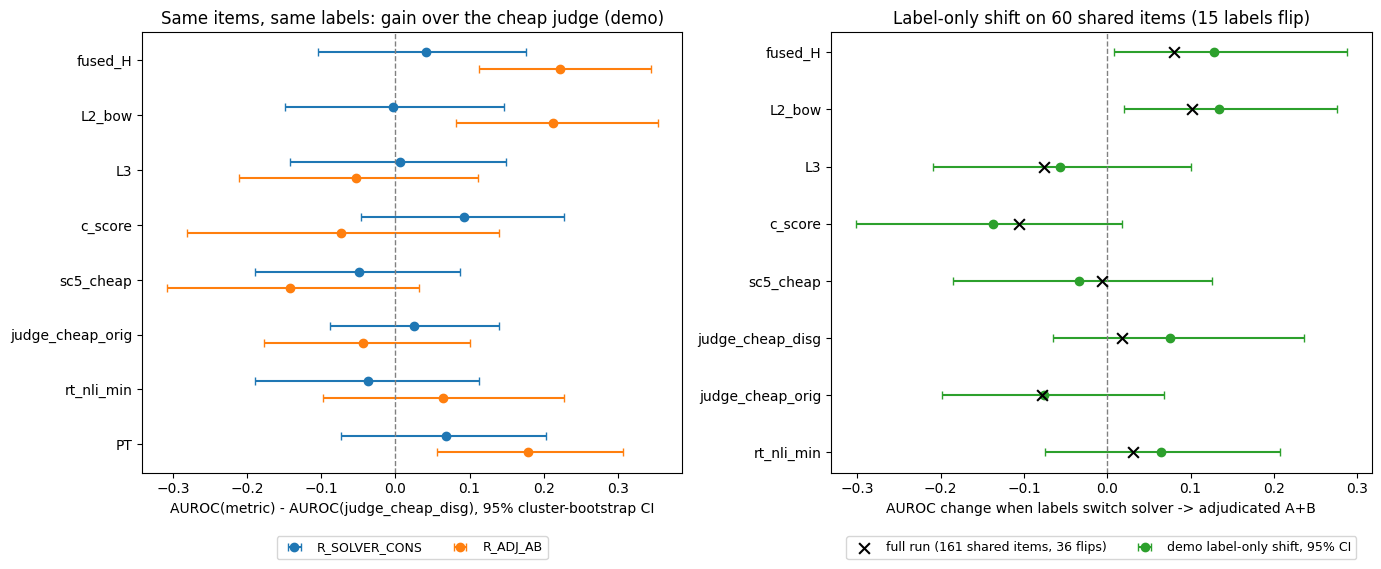

Kendall tau-b of metric rankings, R_SOLVER_CONS vs R_ADJ_AB: {'kendall_tau_b': 0.317, 'ci_lo': 0.026, 'ci_hi': 0.663} (full run: 0.60)
PT minus judge_cheap_disg under R_SOLVER_CONS: +0.068  CI [-0.073, 0.203]
PT minus judge_cheap_disg under R_ADJ_AB: +0.179  CI [0.056, 0.307]
PT minus judge_cheap_disg under R_ADJ_ALL: +0.090  CI [-0.016, 0.198]
(full run: +0.089 solver, +0.104 A+B, +0.090 all tiers)
total analysis time: 20s; tables written to ./tables/


In [21]:
KEY = ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig", "rt_nli_min", "PT_oof"]
ref = {r["metric"]: r for r in data["full_run_reference"]["auroc_matrix"]}
rows = []
for m in KEY:
    r = {"metric": sc.nice(m)}
    for rn in ("R_SOLVER_CONS", "R_ADJ_AB"):
        r[f"demo {rn}"] = r5["matrix"].loc[m, rn] if m in r5["matrix"].index else np.nan
        r[f"full {rn}"] = ref.get(m, {}).get(rn, np.nan)
    rows.append(r)
summary = pd.DataFrame(rows).set_index("metric")
print(f"Demo common sets: R_SOLVER_CONS n={decl['R_SOLVER_CONS']['common_set']['n']} (err {decl['R_SOLVER_CONS']['common_set']['n_err']}), "
      f"R_ADJ_AB n={decl['R_ADJ_AB']['common_set']['n']} (err {decl['R_ADJ_AB']['common_set']['n_err']}); "
      f"full run: 373/155 and 298/165")
print(summary.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
# (a) delta vs cheap judge, both regimes
ax = axes[0]
plot_m = [m for m in KEY if m != sc.REF]
for j, (rn, col) in enumerate([("R_SOLVER_CONS", "tab:blue"), ("R_ADJ_AB", "tab:orange")]):
    t = common_out[rn]["table"].query("item_set == 'COMMON'").set_index("col")
    ms = [m for m in plot_m if m in t.index]
    yv = np.arange(len(ms)) + (j - 0.5) * 0.3
    d = t.loc[ms, "delta_vs_judge"].values.astype(float)
    lo = t.loc[ms, "delta_ci_lo"].values.astype(float)
    hi = t.loc[ms, "delta_ci_hi"].values.astype(float)
    ax.errorbar(d, yv, xerr=[d - lo, hi - d], fmt="o", color=col, capsize=3, label=rn)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_yticks(np.arange(len(plot_m)))
ax.set_yticklabels([sc.nice(m) for m in plot_m])
ax.invert_yaxis()
ax.set_xlabel("AUROC(metric) - AUROC(judge_cheap_disg), 95% cluster-bootstrap CI")
ax.set_title("Same items, same labels: gain over the cheap judge (demo)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=9)
# (b) label-only shift solver -> A+B, demo vs full
ax = axes[1]
sh = r5["shift"].query("`from` == 'R_SOLVER_CONS' and to == 'R_ADJ_AB'").set_index("metric")
names = [sc.nice(m) for m in KEY if sc.nice(m) in sh.index]
yv = np.arange(len(names))
d = sh.loc[names, "label_only_shift"].values.astype(float)
lo = sh.loc[names, "label_only_ci_lo"].values.astype(float)
hi = sh.loc[names, "label_only_ci_hi"].values.astype(float)
ax.errorbar(d, yv, xerr=[d - lo, hi - d], fmt="o", color="tab:green", capsize=3, label="demo label-only shift, 95% CI")
full_sh = {r["metric"]: r["label_only_shift"] for r in data["full_run_reference"]["label_only_shift_solver_to_AB"]}
ax.scatter([full_sh.get(n, np.nan) for n in names], yv, marker="x", color="k", s=60, zorder=3, label="full run (161 shared items, 36 flips)")
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_yticks(yv)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("AUROC change when labels switch solver -> adjudicated A+B")
ax.set_title(f"Label-only shift on {int(sh.n_shared.iloc[0]) if len(sh) else 0} shared items ({int(sh.n_label_changes.iloc[0]) if len(sh) else 0} labels flip)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

tau = r5["tau"].set_index(["regime_1", "regime_2"])
if ("R_SOLVER_CONS", "R_ADJ_AB") in tau.index:
    print("Kendall tau-b of metric rankings, R_SOLVER_CONS vs R_ADJ_AB:", tau.loc[("R_SOLVER_CONS", "R_ADJ_AB")][["kendall_tau_b", "ci_lo", "ci_hi"]].round(3).to_dict(), "(full run: 0.60)")
pt = OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_peer_text_preview"]
for rn in ("R_SOLVER_CONS", "R_ADJ_AB", "R_ADJ_ALL"):
    if "delta_PT_oof_vs_judge_cheap_disg" in pt.get(rn, {}):
        dd = pt[rn]["delta_PT_oof_vs_judge_cheap_disg"]
        print(f"PT minus judge_cheap_disg under {rn}: {dd['delta']:+.3f}  CI {np.round(dd['ci'], 3).tolist()}")
print("(full run: +0.089 solver, +0.104 A+B, +0.090 all tiers)")
print(f"total analysis time: {time.time() - t0:.0f}s; tables written to ./{TAB}/")